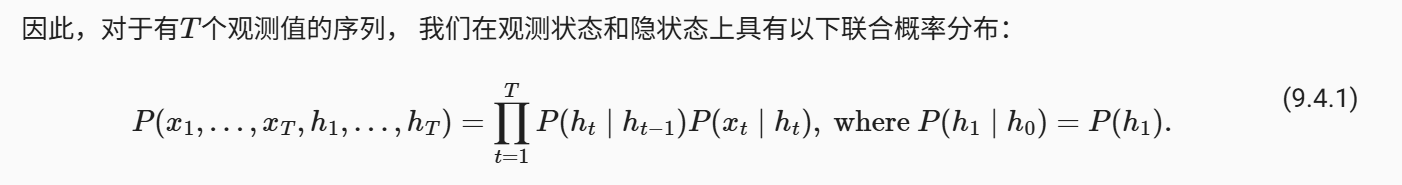

#### 这里理解为两个假设
1. 齐次马尔可夫假设：当前隐状态ht和上一个隐状态ht-1有关，跟其余隐状态无关
2. 观测独立性假设：当前观察xt只和当前ht有关，和其余时刻的观察及隐状态无关
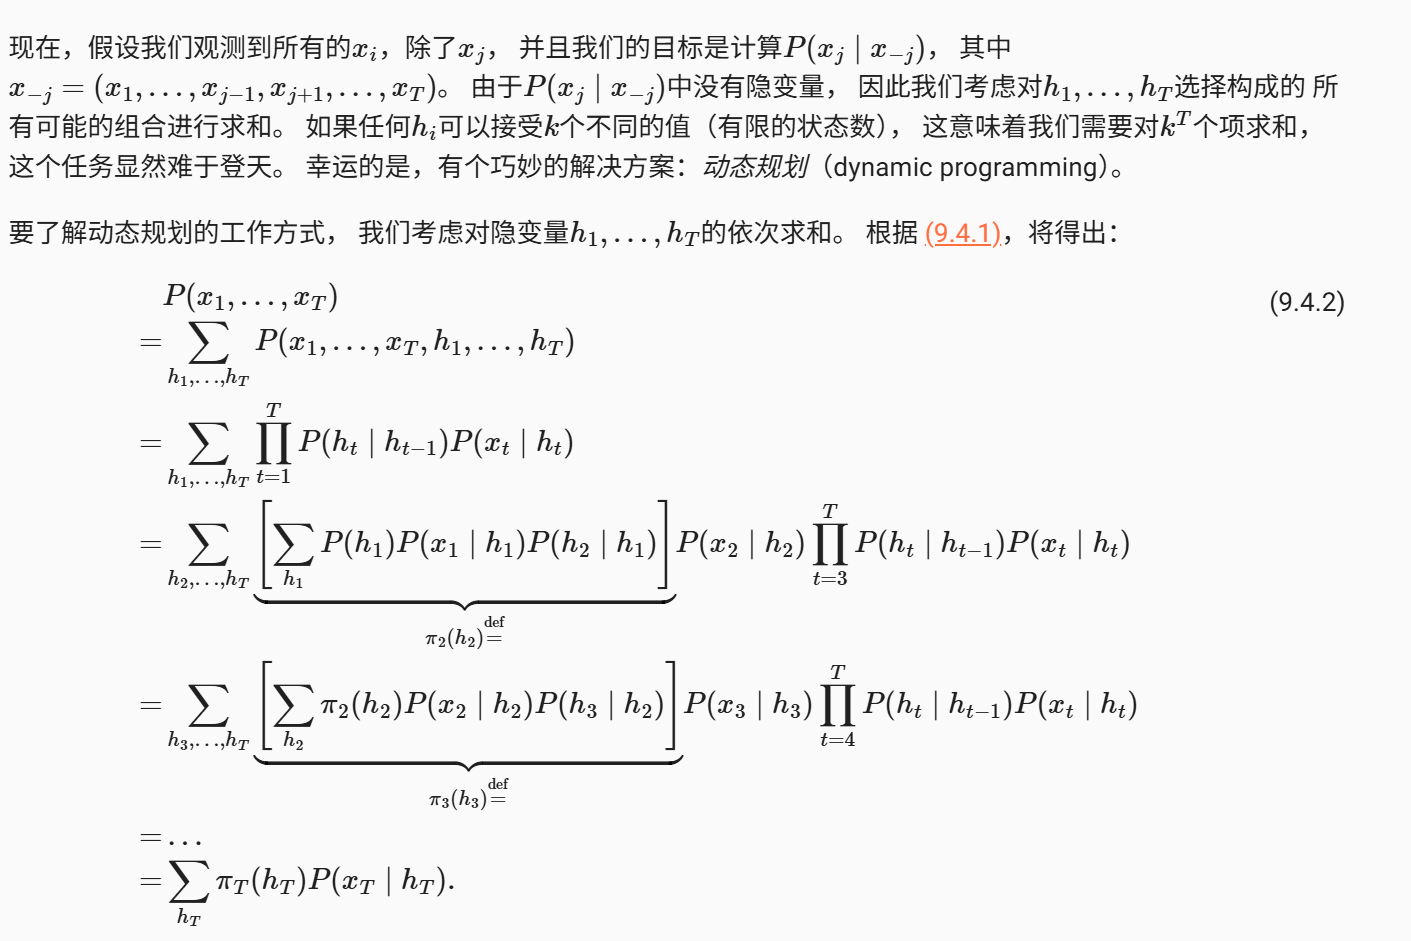
3. 这里的操作将穷举K^T次复杂度降低到了T*k^2

time traveller                                                  
time traveller                                                  
time travellereeeeeeeeeeeeeeeeeeeeeeeeeeeeeeeeeeeeeeeeeeeeeeeeee
time travellereeeeeeeeeeeeeeeeeeeeeeeeeeeeeeeeeeeeeeeeeeeeeeeeee
time travellerrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrr
time travellerererererererererererererererererererererererererer
time travellerererererererererererererererererererererererererer
time travellerererererererererererererererererererererererererer
time travellerererererererererererererererererererererererererer
time travellerererererererererererererererererererererererererer
time travellerererererererererererererererererererererererererer
time travellerererererererererererererererererererererererererer
time travellerererererererererererererererererererererererererer
time travellerererererererererererererererererererererererererer
time travellerererererererererererererererererererererererererer
time travellerererererere

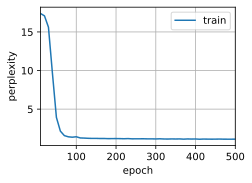

In [1]:
import torch
from torch import nn
from d2l import torch as d2l

# 加载数据
batch_size, num_steps, device = 32, 35, d2l.try_gpu()
train_iter, vocab = d2l.load_data_time_machine(batch_size, num_steps)
# 通过设置“bidirective=True”来定义双向LSTM模型
vocab_size, num_hiddens, num_layers = len(vocab), 256, 2
num_inputs = vocab_size
lstm_layer = nn.LSTM(num_inputs, num_hiddens, num_layers, bidirectional=True)
model = d2l.RNNModel(lstm_layer, len(vocab))
model = model.to(device)
# 训练模型
num_epochs, lr = 500, 1
d2l.train_ch8(model, train_iter, vocab, lr, num_epochs, device)

由于训练可以拿到未来数据Tt+1来做训练，但预测不行，因此双向rnn几乎不用于推理

bi-rnn很多用于序列抽取特征，翻译等